# 02 · Deep-Dive Verification & Final Patient Selection
## ICU Virtual Patient Feed — SASI Use Case B

This notebook verifies the 9 shortlisted candidates before locking in the final 3–4 patients.

### How to use this notebook

The heavy MIMIC table scans (`chartevents`, `inputevents` — each several GB) only run **once**.
After the first run they are saved as small Parquet files in `data/cache/`.
Every subsequent run skips the scan entirely and loads from cache in seconds.

```
First run:   Setup → [slow scan ~5–10 min] → save cache → Analysis
Later runs:  Setup → [fast cache load ~2 s]             → Analysis
```

**The only cell you ever need to edit** is the path config cell directly below.

---

### Structure
| Section | What it does | Speed |
|---|---|---|
| **1 · Setup** | Imports, paths, candidate list | instant |
| **2 · Data** | Smart load: cache or scan MIMIC | slow once, instant after |
| **3 · Diagnoses & Procedures** | Clinical coherence check | instant |
| **4 · ECG File Integrity** | Verify WFDB files exist and load | fast |
| **5 · Drug + Vitals Plots** | Visual sanity check per patient | instant |
| **6 · Final Selection** | Lock in the 3–4 patients | you fill this in |


In [3]:
pip install wfdb

  Using cached wfdb-4.3.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached aiohttp-3.14.1-cp311-cp311-win_amd64.whl.metadata (8.5 kB)
  Using cached fsspec-2026.6.0-py3-none-any.whl.metadata (10 kB)
  Using cached soundfile-0.14.0-py2.py3-none-win_amd64.whl.metadata (18 kB)
  Using cached aiohappyeyeballs-2.6.2-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached frozenlist-1.8.0-cp311-cp311-win_amd64.whl.metadata (21 kB)
  Using cached multidict-6.7.1-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached propcache-0.5.2-cp311-cp311-win_amd64.whl.metadata (17 kB)
  Using cached yarl-1.24.2-cp311-cp311-win_amd64.whl.metadata (97 kB)
Using cached wfdb-4.3.1-py3-none-any.whl (163 kB)
Using cached aiohttp-3.14.1-cp311-cp311-win_amd64.whl (483 kB)
Using cached fsspec-2026.6.0-py3-none-any.whl (203 kB)
Using cached soundfile-0.14.0-py2.py3-none-win_amd64.whl (1.0 MB)
Using cached aiohappyeyeballs-2.6.2-py3-none-any.whl (15 


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

try:
    import wfdb
    HAVE_WFDB = True
except ImportError:
    HAVE_WFDB = False
    print("⚠️  wfdb not installed — ECG file check will be skipped.")
    print("   Run:  pip install wfdb")

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 80)
print("✅ Imports OK")


✅ Imports OK


In [5]:
# ── PATH CONFIG — edit these two lines if needed ──────────────────────────────
#
#   MIMIC_ROOT  should contain:  hosp/  and  icu/
#   ECG_ROOT    should contain:  record_list.csv  and  files/
#
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "scripts" else CURRENT_DIR

MIMIC_ROOT = PROJECT_ROOT / "data" / "external" / "mimic-iv-3.1"
ECG_ROOT   = PROJECT_ROOT / "data" / "external" / "mimic-iv-ecg"
CACHE_DIR  = PROJECT_ROOT / "data" / "cache"

CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ── Sanity check ──────────────────────────────────────────────────────────────
checks = {
    "MIMIC hosp/":       MIMIC_ROOT / "hosp",
    "MIMIC icu/":        MIMIC_ROOT / "icu",
    "ECG record_list":   ECG_ROOT / "record_list.csv",
    "ECG files/":        ECG_ROOT / "files",
}
all_ok = True
for label, path in checks.items():
    ok = path.exists()
    all_ok = all_ok and ok
    print(f"  {'✅' if ok else '❌'}  {label:25s}  {path}")

if all_ok:
    print("\n✅ All paths found — ready to run.")
else:
    print("\n❌ Fix the paths above before continuing.")


  ✅  MIMIC hosp/                c:\Users\dalia\OneDrive\Dokumente\Praktikum2026\SASISimulator\data\external\mimic-iv-3.1\hosp
  ✅  MIMIC icu/                 c:\Users\dalia\OneDrive\Dokumente\Praktikum2026\SASISimulator\data\external\mimic-iv-3.1\icu
  ✅  ECG record_list            c:\Users\dalia\OneDrive\Dokumente\Praktikum2026\SASISimulator\data\external\mimic-iv-ecg\record_list.csv
  ✅  ECG files/                 c:\Users\dalia\OneDrive\Dokumente\Praktikum2026\SASISimulator\data\external\mimic-iv-ecg\files

✅ All paths found — ready to run.


---
## Section 1 · Candidates

All 9 candidates in one unified list: the original 7 deep-dive patients plus the 2 new ones
(7 concurrent drugs and 28 ECGs) added after the first visual review.

Adjust the `note` field freely — it appears in plot titles and the HTML report.


In [6]:
ALL_CANDIDATES = [
    # ── Original 7 ──────────────────────────────────────────────────────────
    {"subject_id": 18772457, "stay_id": 30294277, "hadm_id": 26972341,
     "note": "Top score — CCU, liver transplant (likely exclude)"},
    {"subject_id": 16179553, "stay_id": 38224135, "hadm_id": 25052613,
     "note": "Top CVICU — mitral valve + ECMO + tamponade ✓"},
    {"subject_id": 17520318, "stay_id": 30682249, "hadm_id": 23431795,
     "note": "CVICU — CABG + AVR + septic shock, 7 drugs ✓"},
    {"subject_id": 13269747, "stay_id": 31792549, "hadm_id": 25584074,
     "note": "CCU — AFib + heart failure, 16 ECGs ✓"},
    {"subject_id": 18550032, "stay_id": 32792976, "hadm_id": 23897861,
     "note": "MICU — liver cirrhosis + septic shock (likely exclude)"},
    {"subject_id": 15675070, "stay_id": 34030023, "hadm_id": 25828245,
     "note": "MICU/SICU — pancreatitis + SIRS (likely exclude)"},
    {"subject_id": 15958770, "stay_id": 35600501, "hadm_id": 24895093,
     "note": "TSICU — leukemia + SAH (likely exclude)"},
    # ── 2 New candidates ────────────────────────────────────────────────────
    {"subject_id": 15906662, "stay_id": 36609534, "hadm_id": 24072687,
     "note": "CVICU — 7 simultaneous drugs (new candidate)"},
    {"subject_id": 13408370, "stay_id": 30547595, "hadm_id": 27107260,
     "note": "CCU — 28 ECGs in window (new candidate)"},
]

candidates_df = pd.DataFrame(ALL_CANDIDATES)

# Constants used across all sections
VASOACTIVE_PATTERNS    = ["norepinephrine","noradrenaline","epinephrine","adrenaline",
                           "phenylephrine","vasopressin","dopamine","dobutamine","milrinone"]
ANTIARRHYTHMIC_PATTERNS = ["amiodarone","metoprolol","esmolol","diltiazem","digoxin"]
RELEVANT_DRUG_PATTERNS = VASOACTIVE_PATTERNS + ANTIARRHYTHMIC_PATTERNS
VITAL_ITEMS            = {220045: "heart_rate", 220052: "map", 220277: "spo2"}
ECG_WINDOW_HOURS       = 48

ALL_STAY_IDS  = set(candidates_df["stay_id"])
ALL_HADM_IDS  = set(candidates_df["hadm_id"])
ALL_SUBJ_IDS  = set(candidates_df["subject_id"])

print(f"✅ {len(candidates_df)} candidates defined")
candidates_df[["subject_id","stay_id","first_careunit" if "first_careunit" in candidates_df.columns else "note",
               "note"]].rename(columns={"note":"description"})


✅ 9 candidates defined


,subject_id,stay_id,description,description
0,18772457,30294277,"Top score — CCU, liver transplant (likely exclude)","Top score — CCU, liver transplant (likely exclude)"
1,16179553,38224135,Top CVICU — mitral valve + ECMO + tamponade ✓,Top CVICU — mitral valve + ECMO + tamponade ✓
2,17520318,30682249,"CVICU — CABG + AVR + septic shock, 7 drugs ✓","CVICU — CABG + AVR + septic shock, 7 drugs ✓"
3,13269747,31792549,"CCU — AFib + heart failure, 16 ECGs ✓","CCU — AFib + heart failure, 16 ECGs ✓"
4,18550032,32792976,MICU — liver cirrhosis + septic shock (likely exclude),MICU — liver cirrhosis + septic shock (likely exclude)
5,15675070,34030023,MICU/SICU — pancreatitis + SIRS (likely exclude),MICU/SICU — pancreatitis + SIRS (likely exclude)
6,15958770,35600501,TSICU — leukemia + SAH (likely exclude),TSICU — leukemia + SAH (likely exclude)
7,15906662,36609534,CVICU — 7 simultaneous drugs (new candidate),CVICU — 7 simultaneous drugs (new candidate)
8,13408370,30547595,CCU — 28 ECGs in window (new candidate),CCU — 28 ECGs in window (new candidate)


---
## Section 2 · Data — Smart Cache

The cell below checks whether the cache files already exist.

- **If yes → loads in ~2 seconds.** Skip to Section 3.
- **If no → scans MIMIC (5–10 min), then saves cache.** Run once, never again.

The cache stores 5 Parquet files (one per table subset, filtered to our 9 patients only):

```
data/cache/
├── icustays_candidates.parquet       ~  2 KB
├── diagnoses_candidates.parquet      ~ 30 KB
├── procedures_candidates.parquet     ~ 15 KB
├── drugs_candidates.parquet          ~ 80 KB
└── vitals_candidates.parquet         ~  2 MB
```

> **Tip:** If you add new candidates to `ALL_CANDIDATES` above, delete the cache files
> and re-run this cell so the scan picks up the new stay IDs.


In [7]:
# ── SMART CACHE: load if available, scan MIMIC if not ─────────────────────────

CACHE_FILES = {
    "icustays":   CACHE_DIR / "icustays_candidates.parquet",
    "diagnoses":  CACHE_DIR / "diagnoses_candidates.parquet",
    "procedures": CACHE_DIR / "procedures_candidates.parquet",
    "drugs":      CACHE_DIR / "drugs_candidates.parquet",
    "vitals":     CACHE_DIR / "vitals_candidates.parquet",
    "ecgs":       CACHE_DIR / "ecgs_candidates.parquet",
}

cache_complete = all(f.exists() for f in CACHE_FILES.values())

if cache_complete:
    # ── FAST PATH ─────────────────────────────────────────────────────────────
    print("✅ Cache found — loading from Parquet (fast path)...")
    icustays_c   = pd.read_parquet(CACHE_FILES["icustays"])
    diagnoses_c  = pd.read_parquet(CACHE_FILES["diagnoses"])
    procedures_c = pd.read_parquet(CACHE_FILES["procedures"])
    drugs_c      = pd.read_parquet(CACHE_FILES["drugs"])
    vitals_c     = pd.read_parquet(CACHE_FILES["vitals"])
    ecgs_c       = pd.read_parquet(CACHE_FILES["ecgs"])
    print(f"   icustays:   {len(icustays_c):>6,} rows")
    print(f"   diagnoses:  {len(diagnoses_c):>6,} rows")
    print(f"   procedures: {len(procedures_c):>6,} rows")
    print(f"   drugs:      {len(drugs_c):>6,} rows")
    print(f"   vitals:     {len(vitals_c):>6,} rows")
    print(f"   ecgs:       {len(ecgs_c):>6,} rows")
    print("\nReady — jump to Section 3.")

else:
    # ── SLOW PATH (runs once) ─────────────────────────────────────────────────
    print("⏳ No cache found — scanning MIMIC tables (this takes 5–10 min)...")
    print("   After this run, re-running takes ~2 seconds.\n")

    # 1. ICU stays (tiny table — fast)
    print("  [1/6] icustays...")
    icustays_full = pd.read_csv(MIMIC_ROOT / "icu" / "icustays.csv.gz",
                                 parse_dates=["intime","outtime"])
    icustays_c = icustays_full[icustays_full["stay_id"].isin(ALL_STAY_IDS)].copy()

    # 2. Diagnoses (medium table — fast)
    print("  [2/6] diagnoses_icd + d_icd_diagnoses...")
    diagnoses_raw = pd.read_csv(MIMIC_ROOT / "hosp" / "diagnoses_icd.csv.gz")
    d_diag        = pd.read_csv(MIMIC_ROOT / "hosp" / "d_icd_diagnoses.csv.gz")
    diagnoses_c   = (diagnoses_raw[diagnoses_raw["hadm_id"].isin(ALL_HADM_IDS)]
                     .merge(d_diag, on=["icd_code","icd_version"], how="left"))

    # 3. Procedures (medium table — fast)
    print("  [3/6] procedures_icd + d_icd_procedures...")
    procedures_raw = pd.read_csv(MIMIC_ROOT / "hosp" / "procedures_icd.csv.gz")
    d_proc         = pd.read_csv(MIMIC_ROOT / "hosp" / "d_icd_procedures.csv.gz")
    procedures_c   = (procedures_raw[procedures_raw["hadm_id"].isin(ALL_HADM_IDS)]
                      .merge(d_proc, on=["icd_code","icd_version"], how="left"))

    # 4. Drug item IDs from d_items
    print("  [4/6] inputevents (chunked — largest table)...")
    d_items       = pd.read_csv(MIMIC_ROOT / "icu" / "d_items.csv.gz")
    pattern       = "|".join(RELEVANT_DRUG_PATTERNS)
    relevant_items = d_items[d_items["label"].str.contains(pattern, case=False, na=False)]
    relevant_ids   = set(relevant_items["itemid"])

    # Chunked scan of inputevents
    drug_chunks = []
    for chunk in pd.read_csv(MIMIC_ROOT / "icu" / "inputevents.csv.gz",
                              usecols=["subject_id","stay_id","itemid","starttime","endtime","rate","rateuom"],
                              parse_dates=["starttime","endtime"], chunksize=2_000_000):
        sub = chunk[chunk["stay_id"].isin(ALL_STAY_IDS) & chunk["itemid"].isin(relevant_ids)]
        if len(sub): drug_chunks.append(sub)

    drugs_c = (pd.concat(drug_chunks, ignore_index=True)
               .merge(relevant_items[["itemid","label"]], on="itemid", how="left"))

    # 5. Vitals — chunked scan of chartevents (the very large one)
    print("  [5/6] chartevents (chunked — this is the slow one)...")
    vital_chunks = []
    for chunk in pd.read_csv(MIMIC_ROOT / "icu" / "chartevents.csv.gz",
                              usecols=["subject_id","stay_id","itemid","charttime","valuenum"],
                              parse_dates=["charttime"], chunksize=5_000_000):
        sub = chunk[chunk["stay_id"].isin(ALL_STAY_IDS) & chunk["itemid"].isin(VITAL_ITEMS)]
        if len(sub):
            sub = sub.copy()
            sub["vital"] = sub["itemid"].map(VITAL_ITEMS)
            vital_chunks.append(sub)

    vitals_c = pd.concat(vital_chunks, ignore_index=True)

    # 6. ECG record list (small)
    print("  [6/6] ECG record_list...")
    ecgs_full = pd.read_csv(ECG_ROOT / "record_list.csv", parse_dates=["ecg_time"])
    # Match within window for each stay
    ecg_parts = []
    for _, row in icustays_c.iterrows():
        ws = row["intime"] - pd.Timedelta(hours=ECG_WINDOW_HOURS)
        we = row["outtime"] + pd.Timedelta(hours=ECG_WINDOW_HOURS)
        part = ecgs_full[(ecgs_full["subject_id"] == row["subject_id"]) &
                         (ecgs_full["ecg_time"] >= ws) &
                         (ecgs_full["ecg_time"] <= we)].copy()
        part["stay_id"] = row["stay_id"]
        ecg_parts.append(part)
    ecgs_c = pd.concat(ecg_parts, ignore_index=True)

    # ── Save all to cache ──────────────────────────────────────────────────────
    print("\n  Saving cache files...")
    icustays_c.to_parquet(CACHE_FILES["icustays"],   index=False)
    diagnoses_c.to_parquet(CACHE_FILES["diagnoses"],  index=False)
    procedures_c.to_parquet(CACHE_FILES["procedures"],index=False)
    drugs_c.to_parquet(CACHE_FILES["drugs"],          index=False)
    vitals_c.to_parquet(CACHE_FILES["vitals"],        index=False)
    ecgs_c.to_parquet(CACHE_FILES["ecgs"],            index=False)

    print(f"\n✅ Scan complete. Cache saved to: {CACHE_DIR}")
    print(f"   drugs:   {len(drugs_c):,} rows")
    print(f"   vitals:  {len(vitals_c):,} rows")
    print(f"   ecgs:    {len(ecgs_c):,} rows")


⏳ No cache found — scanning MIMIC tables (this takes 5–10 min)...
   After this run, re-running takes ~2 seconds.

  [1/6] icustays...
  [2/6] diagnoses_icd + d_icd_diagnoses...
  [3/6] procedures_icd + d_icd_procedures...
  [4/6] inputevents (chunked — largest table)...
  [5/6] chartevents (chunked — this is the slow one)...
  [6/6] ECG record_list...

  Saving cache files...

✅ Scan complete. Cache saved to: c:\Users\dalia\OneDrive\Dokumente\Praktikum2026\SASISimulator\data\cache
   drugs:   2,137 rows
   vitals:  14,429 rows
   ecgs:    103 rows


---
## Section 3 · Clinical Coherence — Diagnoses & Procedures

What actually put each patient in the ICU?

We check that the clinical picture matches what we'd expect for SASI Use Case B:
post-cardiac-surgery or cardiac decompensation with vasoactive/antiarrhythmic drug exposure.
Cases where the primary admission reason is non-cardiac (liver transplant, leukemia, pancreatitis)
are flagged here so we can exclude them consciously.


In [8]:
for _, row in candidates_df.iterrows():
    sid  = row["subject_id"]
    hid  = row["hadm_id"]
    note = row["note"]

    top_diag = (diagnoses_c[diagnoses_c["hadm_id"] == hid]
                .sort_values("seq_num")
                .head(5))
    top_proc = (procedures_c[procedures_c["hadm_id"] == hid]
                .head(5))

    print(f"\n{'─'*70}")
    print(f"  subject {sid}  │  {note}")
    print(f"{'─'*70}")
    print("  Diagnoses:")
    for _, d in top_diag.iterrows():
        print(f"    · {d['long_title']}")
    if len(top_proc):
        print("  Procedures:")
        for _, p in top_proc.iterrows():
            print(f"    · {p['long_title']}")



──────────────────────────────────────────────────────────────────────
  subject 18772457  │  Top score — CCU, liver transplant (likely exclude)
──────────────────────────────────────────────────────────────────────
  Diagnoses:
    · Hepatic encephalopathy
    · Hepatorenal syndrome
    · Acute systolic heart failure
    · Esophageal varices in diseases classified elsewhere, with bleeding
    · Pneumonitis due to inhalation of food or vomitus
  Procedures:
    · Other transplant of liver
    · Insertion of percutaneous external heart assist device
    · Transplant from cadaver
    · Other endoscopy of small intestine
    · Other endoscopy of small intestine

──────────────────────────────────────────────────────────────────────
  subject 16179553  │  Top CVICU — mitral valve + ECMO + tamponade ✓
──────────────────────────────────────────────────────────────────────
  Diagnoses:
    · Rheumatic mitral insufficiency
    · Acute kidney failure with lesion of tubular necrosis
    · Cardi

---
## Section 4 · ECG File Integrity Check

For each candidate, loads the **first** and **last** ECG file in the stay window using `wfdb.rdrecord`.

We are checking:
- **File exists on disk** — no `FAILED` error
- **Correct lead set** — Lead II must be present
- **Correct sampling rate** — should be 500 Hz
- **Signal is not all-NaN** — `any_nan: False` is what we want

A patient with ECG files that fail to load is disqualified regardless of score.


In [9]:
if not HAVE_WFDB:
    print("⚠️  wfdb not installed — skipping ECG file check.")
    print("   Run `pip install wfdb` and re-run this cell.")
else:
    for _, row in candidates_df.iterrows():
        sid     = row["subject_id"]
        stay_id = row["stay_id"]
        note    = row["note"]

        patient_ecgs = ecgs_c[ecgs_c["stay_id"] == stay_id].sort_values("ecg_time")
        n = len(patient_ecgs)

        print(f"\n{'─'*70}")
        print(f"  subject {sid}  │  {n} ECGs in window  │  {note}")
        print(f"{'─'*70}")

        if patient_ecgs.empty:
            print("  ⚠️  No ECGs matched — excluded from waveform track.")
            continue

        for label, ecg_row in [("first", patient_ecgs.iloc[0]),
                                ("last",  patient_ecgs.iloc[-1])]:
            record_path = str(ECG_ROOT / ecg_row["path"])
            try:
                rec     = wfdb.rdrecord(record_path)
                has_ii  = "II" in rec.sig_name
                any_nan = bool(pd.isna(rec.p_signal).any())
                status  = "✅" if (rec.fs == 500 and has_ii and not any_nan) else "⚠️ "
                print(f"  {status} [{label:5s}]  {ecg_row['ecg_time']}  "
                      f"leads={rec.sig_name}  fs={rec.fs}  "
                      f"shape={rec.p_signal.shape}  any_nan={any_nan}")
            except Exception as e:
                print(f"  ❌ [{label:5s}]  FAILED — {e}")



──────────────────────────────────────────────────────────────────────
  subject 18772457  │  12 ECGs in window  │  Top score — CCU, liver transplant (likely exclude)
──────────────────────────────────────────────────────────────────────
  ✅ [first]  2140-12-12 13:00:00  leads=['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']  fs=500  shape=(5000, 12)  any_nan=False
  ✅ [last ]  2140-12-29 08:42:00  leads=['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']  fs=500  shape=(5000, 12)  any_nan=False

──────────────────────────────────────────────────────────────────────
  subject 16179553  │  7 ECGs in window  │  Top CVICU — mitral valve + ECMO + tamponade ✓
──────────────────────────────────────────────────────────────────────
  ✅ [first]  2162-10-31 08:35:00  leads=['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']  fs=500  shape=(5000, 12)  any_nan=False
  ✅ [last ]  2162-11-12 15:39:00  leads=['I', 'II', 'III'

---
## Section 5 · Drug Timeline + Vitals Overlay

One plot per candidate. How to read each plot:

| Element | Meaning |
|---|---|
| **Red line** | Heart rate (HR) — alarm threshold: <45 or >130 |
| **Blue line** | Mean arterial pressure (MAP) — alarm threshold: <65 (dashed blue line) |
| **Green shading** | A relevant drug (vasoactive or antiarrhythmic) is actively running during that period |
| **Dashed lines** | Alarm thresholds: MAP 65 (blue), HR 45 (red) |
| **Vertical spikes** | Almost always measurement artefacts (pressure line flush, sensor re-zero) — not real physiology |

**What we're looking for:** HR or MAP crossing the dashed threshold lines *inside* a green-shaded
region, meaning real clinical instability while on a relevant drug. That's the signal SASI's
PK/PD engine is designed to flag.


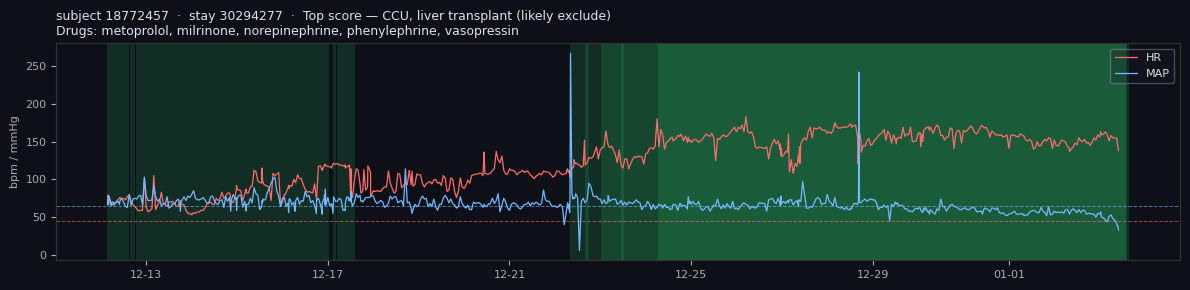

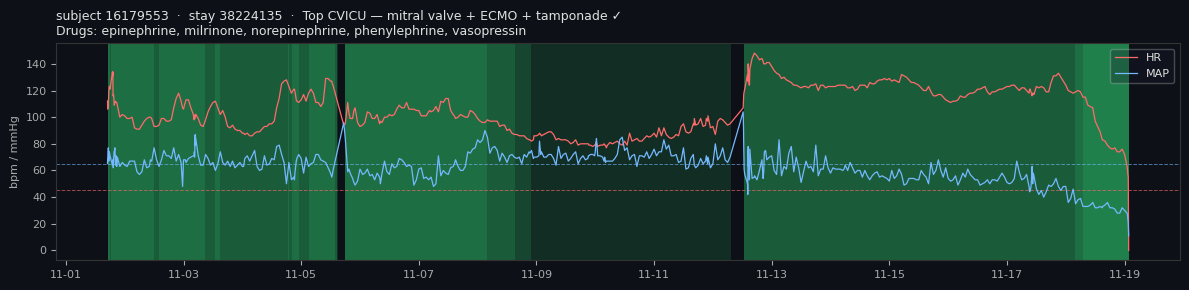

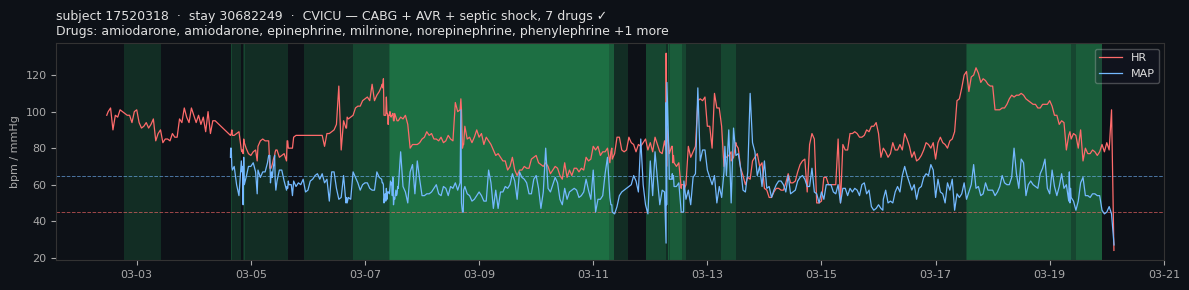

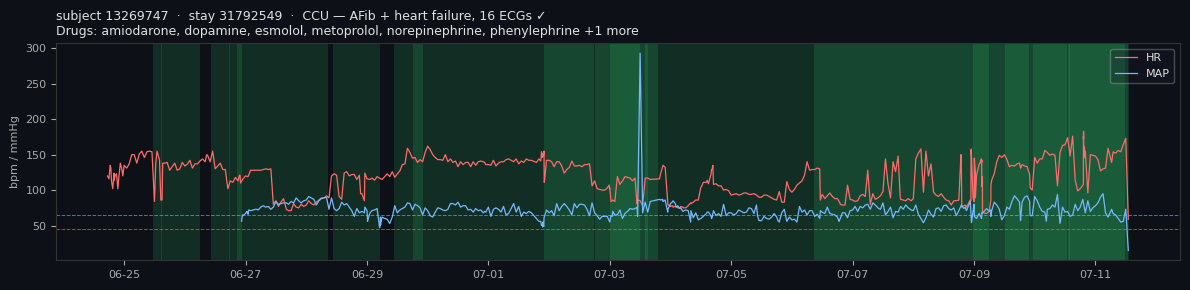

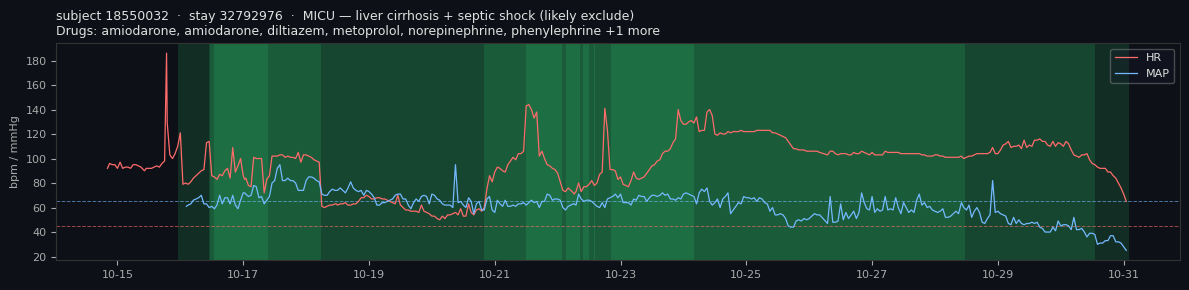

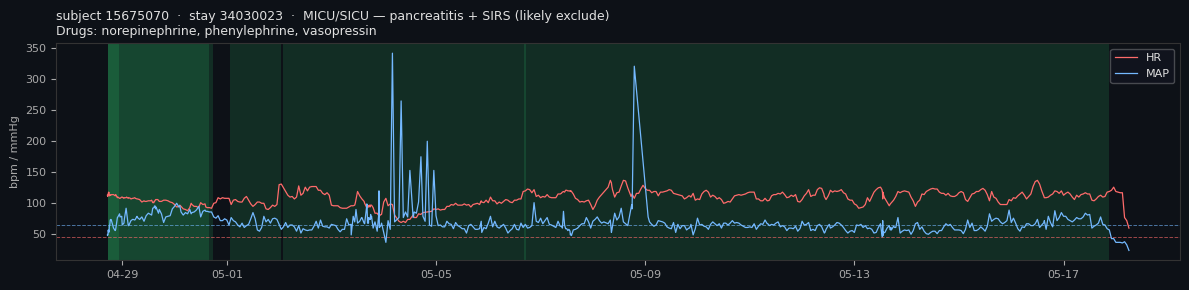

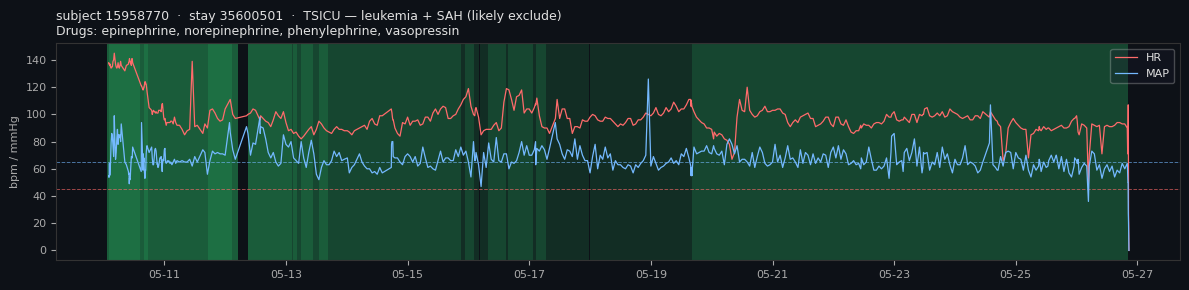

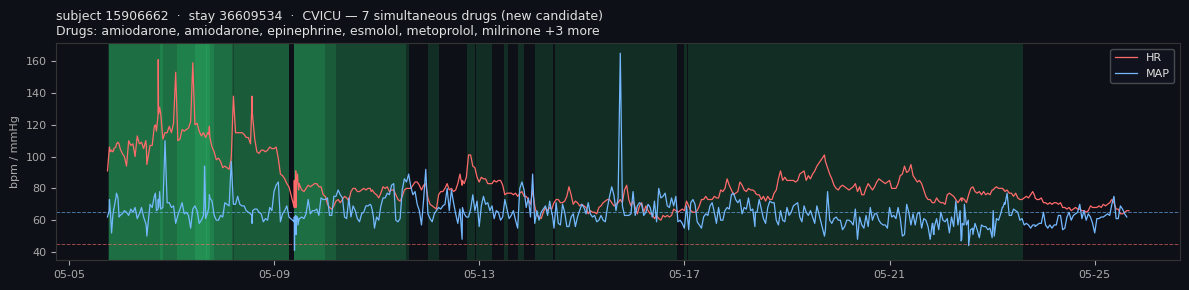

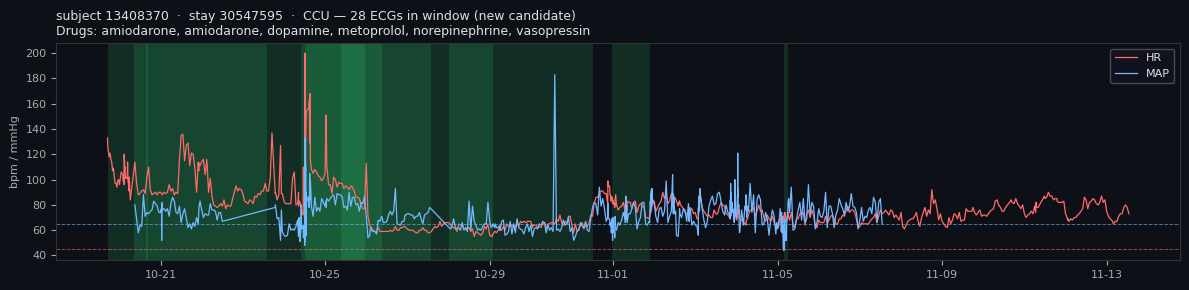

In [10]:
fig_size = (12, 3)

for _, row in candidates_df.iterrows():
    stay_id = row["stay_id"]
    note    = row["note"]
    sid     = row["subject_id"]

    dgrp  = drugs_c[drugs_c["stay_id"] == stay_id]
    vgrp  = vitals_c[vitals_c["stay_id"] == stay_id]

    hr   = vgrp[vgrp["vital"] == "heart_rate"].sort_values("charttime")
    map_ = vgrp[vgrp["vital"] == "map"].sort_values("charttime")

    fig, ax = plt.subplots(figsize=fig_size)
    ax.set_facecolor("#0d1117")
    fig.patch.set_facecolor("#0d1117")

    # Drug shading — one span per infusion row
    for _, drow in dgrp.iterrows():
        ax.axvspan(drow["starttime"], drow["endtime"], alpha=0.12, color="#39ff88", lw=0)

    # Vitals
    if len(hr):
        ax.plot(hr["charttime"], hr["valuenum"],
                color="#ff6b6b", lw=0.9, label="HR", zorder=3)
    if len(map_):
        ax.plot(map_["charttime"], map_["valuenum"],
                color="#74b9ff", lw=0.9, label="MAP", zorder=3)

    # Alarm thresholds
    ax.axhline(65, color="#74b9ff", ls="--", lw=0.7, alpha=0.6)
    ax.axhline(45, color="#ff6b6b", ls="--", lw=0.7, alpha=0.6)

    # Formatting
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax.tick_params(colors="#aaaaaa", labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333333")
    ax.set_ylabel("bpm / mmHg", color="#aaaaaa", fontsize=8)

    drug_names = sorted(dgrp["label"].dropna().unique().tolist())
    short_drugs = ", ".join(d.split()[0].lower() for d in drug_names[:6])
    if len(drug_names) > 6:
        short_drugs += f" +{len(drug_names)-6} more"

    ax.set_title(
        f"subject {sid}  ·  stay {stay_id}  ·  {note}\nDrugs: {short_drugs}",
        color="#e0e0e0", fontsize=9, loc="left", pad=6
    )
    ax.legend(loc="upper right", fontsize=8,
              framealpha=0.3, labelcolor="#e0e0e0", facecolor="#1a1a2e")
    plt.tight_layout()
    plt.show()
    print()


In [12]:
import io
import base64
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── HTML EXPORT INKL. EINGEBETTETER PLOTS (BASE64) ───────────────────────────

html_parts = [
    "<html>",
    "<head>",
    "<meta charset='utf-8'>",
    "<title>ICU Virtual Patient Candidates - SASI Use Case B</title>",
    "<style>",
    "  body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #f4f7f6; color: #333; margin: 40px; }",
    "  h1 { text-align: center; color: #2c3e50; margin-bottom: 40px; }",
    "  .card { background: #fff; border-radius: 8px; padding: 20px; margin-bottom: 30px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); border-left: 6px solid #3498db; }",
    "  .card h2 { margin-top: 0; color: #2980b9; }",
    "  .note { font-style: italic; color: #7f8c8d; margin-bottom: 15px; font-size: 1.1em; background: #ecf0f1; padding: 10px; border-radius: 4px; }",
    "  .section-title { font-weight: bold; margin-top: 20px; color: #2c3e50; border-bottom: 2px solid #eee; padding-bottom: 5px; }",
    "  ul { margin-top: 10px; margin-bottom: 15px; padding-left: 20px; }",
    "  li { margin-bottom: 6px; line-height: 1.4; }",
    "  .warning { color: #e74c3c; font-weight: bold; }",
    "  .success { color: #27ae60; font-weight: bold; }",
    "  .patient-plot { width: 100%; max-width: 1200px; margin-top: 15px; border-radius: 4px; box-shadow: 0 4px 8px rgba(0,0,0,0.2); }",
    "</style>",
    "</head>",
    "<body>",
    "<h1>SASI Use Case B - Candidate Review</h1>"
]

fig_size = (12, 3)

# Iteriere durch alle Kandidaten
for _, row in candidates_df.iterrows():
    sid = row["subject_id"]
    hid = row["hadm_id"]
    stay_id = row["stay_id"]
    note = row["note"]
    
    html_parts.append("<div class='card'>")
    html_parts.append(f"<h2>Patient {sid} │ Stay ID: {stay_id}</h2>")
    html_parts.append(f"<div class='note'>{note}</div>")
    
    # 1. Diagnosen
    top_diag = diagnoses_c[diagnoses_c["hadm_id"] == hid].sort_values("seq_num").head(5)
    html_parts.append("<div class='section-title'>Top 5 Diagnoses:</div><ul>")
    for _, d in top_diag.iterrows():
        html_parts.append(f"<li>{d['long_title']}</li>")
    html_parts.append("</ul>")
    
    # 2. Prozeduren
    top_proc = procedures_c[procedures_c["hadm_id"] == hid].head(5)
    if not top_proc.empty:
        html_parts.append("<div class='section-title'>Procedures:</div><ul>")
        for _, p in top_proc.iterrows():
            html_parts.append(f"<li>{p['long_title']}</li>")
        html_parts.append("</ul>")
        
    # 3. ECG Integrität
    patient_ecgs = ecgs_c[ecgs_c["stay_id"] == stay_id].sort_values("ecg_time")
    n_ecgs = len(patient_ecgs)
    
    html_parts.append(f"<div class='section-title'>ECG Files in Window: {n_ecgs} found</div>")
    if n_ecgs > 0:
        first_ecg = patient_ecgs.iloc[0]['ecg_time']
        last_ecg = patient_ecgs.iloc[-1]['ecg_time']
        html_parts.append(f"<ul>")
        html_parts.append(f"<li><span class='success'>[First]</span> Time: {first_ecg}</li>")
        html_parts.append(f"<li><span class='success'>[Last ]</span> Time: {last_ecg}</li>")
        html_parts.append(f"</ul>")
    else:
        html_parts.append("<p class='warning'>⚠️ No ECGs matched in the timeframe.</p>")
    
    # 4. PLOT ERZEUGEN UND ALS BASE64 EINBETTEN
    dgrp  = drugs_c[drugs_c["stay_id"] == stay_id]
    vgrp  = vitals_c[vitals_c["stay_id"] == stay_id]

    hr   = vgrp[vgrp["vital"] == "heart_rate"].sort_values("charttime")
    map_ = vgrp[vgrp["vital"] == "map"].sort_values("charttime")

    fig, ax = plt.subplots(figsize=fig_size)
    ax.set_facecolor("#0d1117")
    fig.patch.set_facecolor("#0d1117")

    # Drug shading
    for _, drow in dgrp.iterrows():
        ax.axvspan(drow["starttime"], drow["endtime"], alpha=0.12, color="#39ff88", lw=0)

    # Vitals
    if len(hr):
        ax.plot(hr["charttime"], hr["valuenum"], color="#ff6b6b", lw=0.9, label="HR", zorder=3)
    if len(map_):
        ax.plot(map_["charttime"], map_["valuenum"], color="#74b9ff", lw=0.9, label="MAP", zorder=3)

    # Alarm thresholds
    ax.axhline(65, color="#74b9ff", ls="--", lw=0.7, alpha=0.6)
    ax.axhline(45, color="#ff6b6b", ls="--", lw=0.7, alpha=0.6)

    # Formatting
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax.tick_params(colors="#aaaaaa", labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333333")
    ax.set_ylabel("bpm / mmHg", color="#aaaaaa", fontsize=8)

    drug_names = sorted(dgrp["label"].dropna().unique().tolist())
    short_drugs = ", ".join(d.split()[0].lower() for d in drug_names[:6])
    if len(drug_names) > 6:
        short_drugs += f" +{len(drug_names)-6} more"

    ax.set_title(
        f"subject {sid}  ·  stay {stay_id}  ·  {note}\nDrugs: {short_drugs}",
        color="#e0e0e0", fontsize=9, loc="left", pad=6
    )
    ax.legend(loc="upper right", fontsize=8, framealpha=0.3, labelcolor="#e0e0e0", facecolor="#1a1a2e")
    plt.tight_layout()

    # Bild im Arbeitsspeicher ablegen und in Base64 umwandeln
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', dpi=150)
    plt.close(fig) # Schließt die Grafik, damit das Notebook nicht überladen wird
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    
    # Base64-String als Bild in HTML einbetten
    html_parts.append("<div class='section-title'>Drug Timeline & Vitals Overlay:</div>")
    html_parts.append(f"<img src='data:image/png;base64,{img_base64}' alt='Plot for stay {stay_id}' class='patient-plot'>")

    html_parts.append("</div>") # Ende der Karte

html_parts.append("</body></html>")

# Speichere die Datei ab
output_file = "candidate_results_with_plots.html"
with open(output_file, "w", encoding="utf-8") as f:
    f.write("\n".join(html_parts))

print(f"✅ Die Ergebnisse inklusive der Plots wurden erfolgreich in einer einzigen Datei gespeichert: '{output_file}'!")

✅ Die Ergebnisse inklusive der Plots wurden erfolgreich in einer einzigen Datei gespeichert: 'candidate_results_with_plots.html'!


---
## Section 6 · Final Patient Selection

Review the output of Sections 3–5 for all 9 candidates, then fill in `FINAL_PATIENTS` below.

**Selection criteria (in priority order):**

1. **ECG files load cleanly** — hard requirement; no clean ECG = excluded
2. **Clinically sensible for Use Case B** — cardiac surgery / cardiac decompensation, not
   liver transplant, leukemia, or pancreatitis
3. **Plot shows real instability in a drug-active window** — visible HR/MAP excursion inside
   green shading, not just flat lines or isolated artefact spikes
4. **Drug overlap ≥ 3** — at least 3 relevant drugs running at some point (ideally simultaneously)
5. **ECG density ≥ 5** — enough real waveform records to cover the replay meaningfully

**Recommended from visual review so far:**
- `16179553` — CVICU, mitral valve + ECMO + tamponade ✓  
- `17520318` — CVICU, CABG + AVR + septic shock, 7 drugs ✓  
- `13269747` — CCU, AFib under rate control, 16 ECGs ✓  
- 4th: verify `15906662` (7 concurrent drugs) and `13408370` (28 ECGs) in this run, then decide

Fill in the list below once you have reviewed all plots and diagnostics above.


In [1]:
FINAL_PATIENTS = [
    {"subject_id": 16179553, "stay_id": 38224135, "hadm_id": 25052613,
     "label": "CVICU — mitral valve replacement + ECMO + cardiogenic shock"},
    {"subject_id": 17520318, "stay_id": 30682249, "hadm_id": 23431795,
     "label": "CVICU — CABG + AVR + septic shock, 7 drugs"},
    {"subject_id": 13269747, "stay_id": 31792549, "hadm_id": 25584074,
     "label": "CCU — AFib under rate control, 16 ECGs"},
    {"subject_id": 13408370, "stay_id": 30547595, "hadm_id": 27107260,
     "label": "CCU — anterior MI + VF arrest + AICD, 28 ECGs"},
    {"subject_id": 15906662, "stay_id": 36609534, "hadm_id": 24072687,
     "label": "CVICU — AMI + multi-vessel CABG + cardiogenic shock, 7 drugs"},
]

if FINAL_PATIENTS:
    print("✅ Final patients locked:")
    for p in FINAL_PATIENTS:
        print(f"  · subject {p['subject_id']:>10}  →  {p['label']}")
    print("\nNext step: run 03_build_timelines.ipynb for these patients.")
else:
    print("⬆️  Fill in FINAL_PATIENTS above after reviewing the outputs.")


✅ Final patients locked:
  · subject   16179553  →  CVICU — mitral valve replacement + ECMO + cardiogenic shock
  · subject   17520318  →  CVICU — CABG + AVR + septic shock, 7 drugs
  · subject   13269747  →  CCU — AFib under rate control, 16 ECGs
  · subject   13408370  →  CCU — anterior MI + VF arrest + AICD, 28 ECGs
  · subject   15906662  →  CVICU — AMI + multi-vessel CABG + cardiogenic shock, 7 drugs

Next step: run 03_build_timelines.ipynb for these patients.
